## Beginning of Machine Learning Journey

### Predicting concrete strength

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
## Preparing an Imaginary Random data
## Features (X): [Cement(kg), Water(kg),Fly Ash(kg)]
X= np.array([[300,180,50],
             [400,160,0],
             [200,200,100],
             [350,170,30],
             [500,150,0]])
## Y= Compressive Strength in Mpa after 28 days
y= np.array([35,45,22,38,55])


### Initialising Model

In [3]:
## Using Linear Regression
model= LinearRegression()

## Training the Model
model.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.25, 1.55,-0.35]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-302.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[240.15, 26.93, 0.85]"


### Making a Prediction of a Brand New Mix

In [4]:
new_mix=np.array([[380,165,20]])
predicted_strength= model.predict(new_mix)

print(f"New Mix Design: {new_mix[0]}")
print(f"Predicted 28-day Compressive Strength: {predicted_strength[0]:.2f} Mpa")

New Mix Design: [380 165  20]
Predicted 28-day Compressive Strength: 41.25 Mpa


### Plot

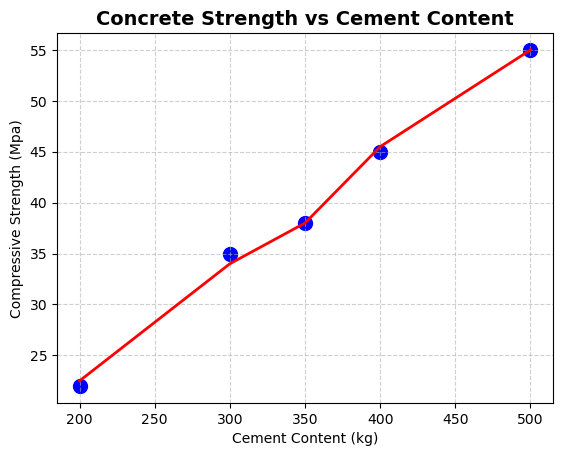

In [5]:
## Plot vs Cement
cement=X[:,0]
prediction= model.predict(X)

plt.scatter(cement,y, color='blue', label='Actual Concrete Data',s=100)

## Due to the graph resulting in two predicted lines we sort the data 
sorted_data= np.argsort(cement)
sorted_cement= cement[sorted_data]
sorted_prediction= prediction[sorted_data]

## plot of predicted relationship line
plt.plot(sorted_cement, sorted_prediction, color='red',linewidth=2, label='Model Prediction Line')

plt.title('Concrete Strength vs Cement Content', fontsize=14, fontweight='bold')
plt.xlabel('Cement Content (kg)', fontsize=10)
plt.ylabel('Compressive Strength (Mpa)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Key Insights

##### The line is irregular or zig-zaged
##### The Reason: This happens because concrete compressive strength is a 'multi-variable problem'. While this 2D graph only shows "Cement Content" on the horizontal axis, the machine learning model is actually calculating strength based on the three inputs simultaneously.
##### The Takeaway: In a true 4-dimensional space, the model's math forms a perfectly flat, straight hyperplane. What we are seeing here is simply a 2D "shadow" or projection of that multi-variable formula.

### 3-D Plot

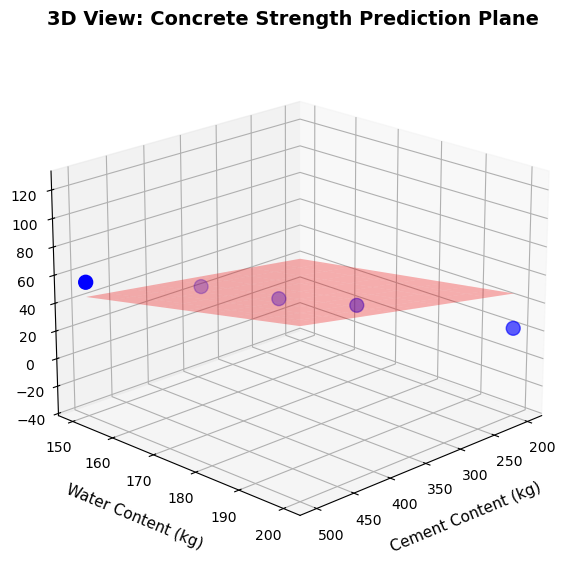

In [6]:

fig=plt.figure(figsize=(10,7))
ax= fig.add_subplot(111, projection='3d')

cement= X[:,0]
water= X[:,1]
strength= y
predicted_strength= model.predict(X)

ax.scatter(cement,water,strength, color='blue',s=100, label='Actual Data')

## Generating a 3D grid to draw the prediction plane
x_plane, y_plane= np.meshgrid(np.linspace(200,500,10),np.linspace(150,200,10))

## Temporarily adjusting value of Fly Ash to 30 kg to render 3D splice

cement_flat= x_plane.flatten()   ## Flatten the 2D grid arrays into simple 1D lists of coordinates
water_flat= y_plane.flatten()

flyash_flat=np.full_like(cement_flat,30)   ##Create a matching list for Fly Ash, locking it at 30kg for every single point

grid_data= np.column_stack((cement_flat, water_flat, flyash_flat)) ## creating a 3-column table
prediction_flat= model.predict(grid_data)

z_plane= prediction_flat.reshape(x_plane.shape)

ax.plot_surface(x_plane, y_plane,z_plane, color='red', alpha=0.3, rstride=1, cstride=1)
ax.view_init(elev=20, azim=45)
ax.set_xlabel('Cement Content (kg)', fontsize=11, labelpad=10)
ax.set_ylabel('Water Content (kg)', fontsize=11, labelpad=10)
ax.set_zlabel('Compressive Strength (MPa)', fontsize=11, labelpad=10)
ax.set_title('3D View: Concrete Strength Prediction Plane', fontsize=14, fontweight='bold')

plt.show()